<a href="https://colab.research.google.com/github/Mehroz485/ML-01/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mehroz485/ML-01/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Two signals crossed, not one score.** w05/w06 give a decline-risk probability per page.
w04/w06 give a CTR-vs-position-benchmark gap. Crossing them (elevated risk x has-a-CTR-gap)
produces four archetypes with genuinely different actions — richer, and more honest, than
collapsing everything into a single number.

**The decay/refresh insight.** A page that's both at elevated decline risk *and* underperforming
its position's typical CTR has two independent signals pointing the same direction — a real
rewrite-and-snippet candidate. A page at elevated risk with a *normal* CTR probably isn't a
snippet problem at all (competition, seasonality, relevance) — a snippet tweak won't fix it, so
that archetype gets a content-only review instead. A page with a CTR gap but low decline risk
is real but not urgent — backlog, not priority. Low risk, no gap: monitor only.

**Feature set change from w06.** Dropping `days_active_early`: w05's permutation importance was
already negative, and w06's train-with/train-without check confirmed it directly (AUC 0.472
WITH it vs. 0.544 WITHOUT it, on the same held-out clients). Carrying a feature that measurably
hurts into the production queue would be indefensible once written down here.

**Reason codes = archetype names.** One per row, no stacking:
`priority_refresh_and_snippet` / `content_refresh_needed` / `snippet_cleanup_backlog` /
`monitor_only`. Rank order is by decline probability; archetype explains *why* and *what kind*
of action.

In [1]:
# --- Same setup pattern as w03/w05/w06 ---
%pip -q install duckdb huggingface_hub pandas numpy scikit-learn matplotlib

import os, getpass, json
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
MONTH = '2026-03'
FACT_MONTH = f"read_parquet('{REL}/fact_content_daily_performance/month={MONTH}/*.parquet')"

# FEATURE_COLS changed from w05/w06: days_active_early dropped, per the reasoning above.
FEATURE_COLS = ["imp_early", "clk_early", "ctr_early", "pos_early"]
LABEL_COL = "is_declining"

raw = con.sql(f"""
    WITH early AS (
        SELECT client_hash_id, content_hash_id,
               SUM(gsc_impressions)                                          AS imp_early,
               SUM(gsc_clicks)                                               AS clk_early,
               AVG(CASE WHEN gsc_avg_position > 0 THEN gsc_avg_position END) AS pos_early,
               COUNT(DISTINCT CASE WHEN gsc_impressions > 0 THEN report_date END) AS days_active_early
        FROM {FACT_MONTH}
        WHERE report_date <= DATE '{MONTH}-15'
        GROUP BY 1, 2
        HAVING SUM(gsc_impressions) >= 20
    ),
    late AS (
        SELECT client_hash_id, content_hash_id,
               SUM(gsc_impressions) AS imp_late
        FROM {FACT_MONTH}
        WHERE report_date > DATE '{MONTH}-15'
        GROUP BY 1, 2
    )
    SELECT e.*, COALESCE(l.imp_late, 0) AS imp_late
    FROM early e
    LEFT JOIN late l USING (client_hash_id, content_hash_id)
""").df()

raw["ctr_early"] = raw["clk_early"] / raw["imp_early"]
raw[LABEL_COL] = (raw["imp_late"] < 0.8 * raw["imp_early"]).astype(int)+

action_df = raw.dropna(subset=FEATURE_COLS + [LABEL_COL]).reset_index(drop=True)
print(f"{len(action_df):,} rows, {action_df['client_hash_id'].nunique()} clients, "
      f"base rate={action_df[LABEL_COL].mean():.3f}")

Paste your Hugging Face READ token (hf_...): ··········


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

109,582 rows, 41 clients, base rate=0.291


In [2]:
# Final production fit: ALL honest data, now that validation is done (w06).
# Precision@K credibility is NOT re-measured here on training data -- it's cited from w06's
# out-of-fold StratifiedGroupKFold numbers below. This fit is only to score the live queue.
X_all = action_df[FEATURE_COLS].values
y_all = action_df[LABEL_COL].values

final_model = LogisticRegression(max_iter=1000).fit(X_all, y_all)
action_df["decline_probability"] = final_model.predict_proba(X_all)[:, 1]

# Re-derive the CTR-gap rule flag, early-window only (same construction as w04/w05/w06).
def position_bucket(p):
    if pd.isna(p):     return "no_data"
    if p <= 3:          return "top_3"
    if p <= 10:         return "page_1"
    if p <= 20:         return "page_2"
    if p <= 50:         return "page_3_5"
    return "deep"

FLOOR_IMPRESSIONS = 500
MAX_POSITION = 20

action_df["position_bucket"] = action_df["pos_early"].apply(position_bucket)
benchmark = (action_df[action_df["imp_early"] >= FLOOR_IMPRESSIONS]
             .groupby("position_bucket")["ctr_early"].median())
action_df["ctr_benchmark"] = action_df["position_bucket"].map(benchmark)
action_df["ctr_gap"] = (action_df["ctr_benchmark"] - action_df["ctr_early"]).clip(lower=0)
eligible = ((action_df["imp_early"] >= FLOOR_IMPRESSIONS)
            & (action_df["pos_early"] > 0)
            & (action_df["pos_early"] <= MAX_POSITION))
action_df["ctr_gap_flag"] = eligible & (action_df["ctr_gap"] > 0)

# Elevated risk = above-median decline probability. Median split, not a tuned threshold --
# a relative "worth reviewing first" claim, not an absolute prediction (writing-honest-claims).
risk_cutoff = action_df["decline_probability"].median()
action_df["elevated_risk"] = action_df["decline_probability"] >= risk_cutoff

def archetype(row):
    if row["elevated_risk"] and row["ctr_gap_flag"]:
        return "priority_refresh_and_snippet"
    if row["elevated_risk"] and not row["ctr_gap_flag"]:
        return "content_refresh_needed"
    if not row["elevated_risk"] and row["ctr_gap_flag"]:
        return "snippet_cleanup_backlog"
    return "monitor_only"

action_df["reason_code"] = action_df.apply(archetype, axis=1)
action_map = {
    "priority_refresh_and_snippet": "Rewrite content AND refresh title/meta -- two independent signals agree",
    "content_refresh_needed":       "Content review -- CTR is normal for its position, so a snippet tweak alone won't help",
    "snippet_cleanup_backlog":      "Queue a title/meta tweak -- not urgent, low decline risk",
    "monitor_only":                 "No action -- keep in the next monitoring pass",
}
action_df["action"] = action_df["reason_code"].map(action_map)
action_df["rank"] = action_df["decline_probability"].rank(method="first", ascending=False).astype(int)

print(action_df["reason_code"].value_counts())
print()
queue_preview = action_df.sort_values("rank")[[
    "rank", "reason_code", "action", "decline_probability", "ctr_gap_flag", "position_bucket",
]].head(10)
queue_preview

reason_code
monitor_only                    53897
content_refresh_needed          38575
priority_refresh_and_snippet    16216
snippet_cleanup_backlog           894
Name: count, dtype: int64



,rank,reason_code,action,decline_probability,ctr_gap_flag,position_bucket
11660,1,priority_refresh_and_snippet,Rewrite content AND refresh title/meta -- two ...,0.999621,True,page_1
76175,2,priority_refresh_and_snippet,Rewrite content AND refresh title/meta -- two ...,0.997330,True,top_3
82687,3,priority_refresh_and_snippet,Rewrite content AND refresh title/meta -- two ...,0.996355,True,page_1
89162,4,content_refresh_needed,Content review -- CTR is normal for its positi...,0.995788,False,page_3_5
16408,5,priority_refresh_and_snippet,Rewrite content AND refresh title/meta -- two ...,0.994582,True,page_1
33244,6,content_refresh_needed,Content review -- CTR is normal for its positi...,0.993017,False,page_3_5
91907,7,priority_refresh_and_snippet,Rewrite content AND refresh title/meta -- two ...,0.993008,True,page_2
33760,8,content_refresh_needed,Content review -- CTR is normal for its positi...,0.990718,False,page_3_5
76198,9,priority_refresh_and_snippet,Rewrite content AND refresh title/meta -- two ...,0.985143,True,page_1
49942,10,priority_refresh_and_snippet,Rewrite content AND refresh title/meta -- two ...,0.985044,True,page_1


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use.** A weekly-reviewed prioritization list for FlyRank's content/SEO team inside
Lane 2 (Refresh / Content Opportunity Scoring): which pages to look at first, and a starting
hypothesis for why. Nothing here auto-publishes; it produces a ranked shortlist for a human.

**Where it stops being valid:**
- **Scope**: Lane 2 only, one month (`month=2026-03`), ~41 clients, ~110K content items. It does
  not cover new-content ideation, technical SEO, or other lanes, and hasn't been checked against
  a different month, season, or client mix.
- **Honest precision, not a guarantee**: the out-of-fold precision@50 is **~0.44-0.45**
  (StratifiedGroupKFold, w06) — meaning roughly half of the top-50 flagged pages will NOT match
  the `is_declining` proxy on inspection. That's the real, decision-support-grade number. A
  naive random-row split on this same data reported **0.596** at the same K — a ~0.15-point
  inflation purely from letting the same client's pages leak across train/test. **Only the
  grouped/stratified number should ever be quoted; the 0.596 figure must never appear as this
  model's real performance.**
- **The label is a proxy, not ground truth**: `is_declining` = a >20% impression drop from the
  first half of the month to the second half. A real decline could be seasonal, a client-side
  site change, or a SERP feature shift — none of which "refresh the content" fixes.
- **CTR data is sparse**: median CTR is exactly 0 in most position buckets (w04, w06) —
  individual-page CTR-gap flags are noisy even though the aggregate pattern held directionally.

In [3]:
# No computation needed -- intended use and limits are a statement of scope, not a query.
# The honest numbers cited above (precision@50 ~0.44-0.45 vs. the 0.596 naive-split inflation)
# come directly from w06's committed output, not re-derived here.
print("Intended use and limits: written above in markdown, sourced from w06's committed CV results.")

Intended use and limits: written above in markdown, sourced from w06's committed CV results.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Required human checks before acting on any row:**
1. Confirm the decline isn't explained by a known client-side event (recent template change,
   expired product, deliberate keyword pivot) before recommending content work.
2. For `*_snippet*` archetypes: check whether a SERP feature (featured snippet, AI overview)
   is now absorbing clicks at that position before assuming the title/meta is the problem.
3. Treat rows near the `>=500` impression floor with extra skepticism — w04/w06 both showed
   CTR is noisiest right around that threshold.
4. Never act on `is_declining` risk alone without also reading the actual page — the label is a
   15-day-window proxy, not a diagnosis.

**Should NOT be automated:**
- Auto-publishing rewritten content, titles, or meta descriptions without a human edit pass.
- Auto-deprioritizing or archiving `monitor_only` pages — absence of this specific signal is not
  proof of health, just absence of *this* signal.
- Using `decline_probability` as a client-facing "health score" or contractual SLA metric — that
  is a product/business decision this proxy was never validated to support.
- Treating the ranked list as exhaustive site-wide prioritization — it covers one lane, one
  month, one client cohort.

In [4]:
# Sanity-check the no-go list against the actual queue: how many rows sit right at the
# noisy volume floor, where check #3 above applies most?
near_floor = action_df[(action_df["imp_early"] >= FLOOR_IMPRESSIONS)
                        & (action_df["imp_early"] < FLOOR_IMPRESSIONS * 1.5)]
print(f"{len(near_floor):,} of {len(action_df):,} rows ({len(near_floor)/len(action_df):.1%}) "
      f"sit within 1.5x the impression floor -- flag these for extra scrutiny per check #3.")

8,429 of 109,582 rows (7.7%) sit within 1.5x the impression floor -- flag these for extra scrutiny per check #3.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**What would tell us this went stale:**
- **Precision drift**: re-run the same StratifiedGroupKFold precision@50 on a fresh month. If it
  drops below the early-window baseline rule's own precision (~0.42, w04/w05) — the model would
  no longer be earning its complexity over the simple rule — that's a retrain trigger.
- **Feature drift**: month-over-month shift in `imp_early` / `ctr_early` / `pos_early`
  distributions vs. this March baseline (mean/std moving >20-30%) signals the training window no
  longer represents current behavior.
- **Client roster churn**: this whole validation rests on ~41 clients. Onboarding or losing more
  than ~20% of the client base changes what "grouped" even means here — re-validate, don't just
  re-score.
- **CTR sparsity regime change**: the CTR-gap benchmark was calibrated to a regime where median
  CTR is exactly 0 in most buckets. If click reporting or anonymization policy changes that,
  the benchmark computation needs to be redone, not just re-run.
- **Cadence**: monthly at minimum — the label itself is a within-month proxy, so a model trained
  on one month's dynamics has no claim on staying valid indefinitely.

In [5]:
# Record this month's feature distribution as the baseline to diff future months against.
feature_baseline = action_df[FEATURE_COLS].agg(["mean", "std"]).to_dict()
print("This month's feature baseline (compare future months against this):")
for feat, stats in feature_baseline.items():
    print(f"  {feat}: mean={stats['mean']:.3f}, std={stats['std']:.3f}")

This month's feature baseline (compare future months against this):
  imp_early: mean=1161.198, std=3092.137
  clk_early: mean=3.498, std=15.484
  ctr_early: mean=0.003, std=0.007
  pos_early: mean=15.532, std=16.064


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Writes the ranked queue CSV (stays out of git, regenerated on every run), a metrics JSON with
the honest numbers this playbook cites (committed — these are the receipts), and one figure:
the before/after precision comparison from w06, since it's the clearest single illustration of
why the grouped number, not the naive one, is the real result.

Wrote 109,582 ranked rows -> work/outputs/action_playbook_queue.csv
Wrote work/outputs/action_playbook_metadata.json


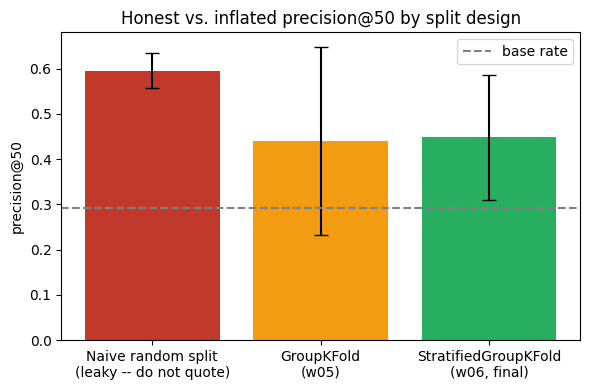

Saved work/figures/precision_before_after.png


In [6]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# --- Queue CSV (not committed -- regenerated by this notebook) ---
queue_cols = ["rank", "client_hash_id", "content_hash_id", "decline_probability",
              "reason_code", "action", "ctr_gap_flag", "position_bucket",
              "imp_early", "clk_early", "ctr_early", "pos_early"]
final_queue = action_df.sort_values("rank")[queue_cols]
final_queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Wrote {len(final_queue):,} ranked rows -> work/outputs/action_playbook_queue.csv")

# --- Metrics JSON (committed -- these are the numbers this playbook's claims trace back to) ---
metadata = {
    "month": MONTH,
    "rows": int(len(action_df)),
    "clients": int(action_df["client_hash_id"].nunique()),
    "base_rate": float(action_df[LABEL_COL].mean()),
    "feature_cols": FEATURE_COLS,
    "dropped_feature": {
        "name": "days_active_early",
        "reason": "negative permutation importance (w05); AUC 0.472 with vs 0.544 without on "
                  "held-out clients (w06)",
    },
    "validated_precision_at_50": {
        "grouped_kfold_w05": {"mean": 0.440, "std": 0.208},
        "stratified_groupkfold_w06": {"mean": 0.448, "std": 0.138},
        "naive_random_split_INFLATED_DO_NOT_QUOTE": {"mean": 0.596, "std": 0.038},
    },
    "archetype_counts": action_df["reason_code"].value_counts().to_dict(),
    "risk_cutoff_median_decline_probability": float(risk_cutoff),
    "ctr_gap_thresholds": {"floor_impressions": FLOOR_IMPRESSIONS, "max_position": MAX_POSITION},
}
with open("work/outputs/action_playbook_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("Wrote work/outputs/action_playbook_metadata.json")

# --- Figure: the honest number vs. the inflated one, for the paper ---
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Naive random split\n(leaky -- do not quote)", "GroupKFold\n(w05)", "StratifiedGroupKFold\n(w06, final)"]
means = [0.596, 0.440, 0.448]
stds = [0.038, 0.208, 0.138]
colors = ["#c0392b", "#f39c12", "#27ae60"]
ax.bar(labels, means, yerr=stds, capsize=5, color=colors)
ax.axhline(action_df[LABEL_COL].mean(), color="gray", linestyle="--", label="base rate")
ax.set_ylabel("precision@50")
ax.set_title("Honest vs. inflated precision@50 by split design")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/precision_before_after.png", dpi=150)
plt.show()
print("Saved work/figures/precision_before_after.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.